## Metric Function

In [31]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

def test(model, X, y):
    preds = model.predict(X)

    cf = confusion_matrix(y, preds)
    sns.heatmap(cf, annot=True, fmt="d")

    # print(preds)
    return classification_report(y, preds, zero_division=1)



def create_data_set(N=1000):
    X = np.random.rand(N, 2)
    y = np.logical_or(X[:, 0] >= 0.5, X[:, 1] >= 0.5).astype(int)

    return X, y


## Logistic Regression with Dimension Extension

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression

def feature_enginnring(X):
    new_X = []
    for x in X:
        new_X.append([x[0], x[1], x[0]*x[1]])

    return new_X


X, y = create_data_set(1000)

custom_preprocessor = FunctionTransformer(feature_enginnring)
XOR_model = Pipeline([('preprocessor',  custom_preprocessor),('model', LogisticRegression(penalty=None))])

XOR_model.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function fea...x785b62bdee80>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


              precision    recall  f1-score   support

           0       0.93      0.91      0.92       247
           1       0.97      0.98      0.97       753

    accuracy                           0.96      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.96      0.96      1000



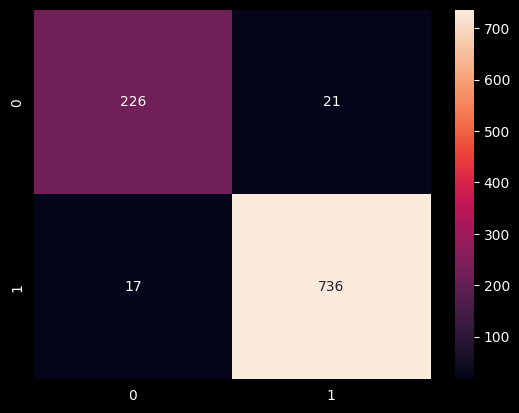

In [33]:
cr = test(XOR_model, X, y)
print(cr)

## Decision boundry

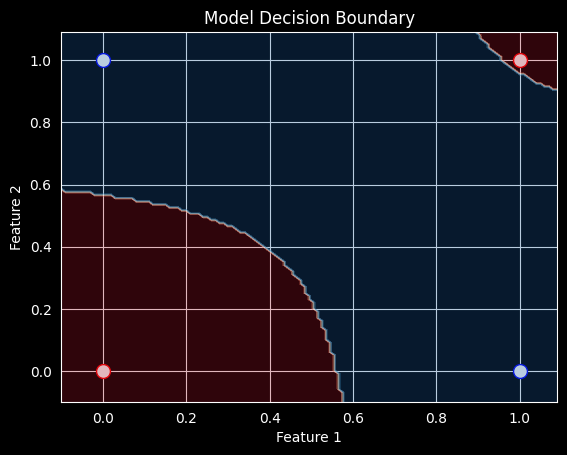

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1


    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))


    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.scatter(x = [1,0], y = [0,1], color = 'white', edgecolors = 'blue', s=100)
    plt.scatter(x = [0,1], y = [0,1], color = 'white', edgecolors = 'red', s=100)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.title("Model Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Usage:
plot_decision_boundary(XOR_model, X, y)